# Overnight Results: The Greedy-Policy-Collapse Fix

**Branch**: `feature/uncertainty-exploration-and-oracle` (unmerged -- awaiting review)
**Companion doc**: `docs/INVESTIGATION_GRAPH_HEAD_REGRESSION.md`, sections from "CRITICAL: frozen evaluation..." onward

This notebook visualizes every piece of evidence behind one night's work:

1. A critical bug in frozen evaluation (found while building the oracle-agreement metric) that silently ignored each checkpoint's actual training config
2. The 24-run estimator comparison matrix, re-evaluated with the fix
3. **The headline result**: an uncertainty-driven exploration bonus (Track B) that took frozen-policy success from ~0-4% to a verified 20.8-54.2% -- including the correction I made to my own first (overstated) reading of the numbers
4. A full-scale (1000-episode) confirmatory run showing more training data alone does *not* fix the collapse

All data was pulled from Myriad HPC diagnostic-scale (200-episode) and full-scale (1000-episode) runs.


In [1]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
})
COLORS = {"pre-fix": "#9e9e9e", "UCB-only": "#e57373", "uncertainty": "#2e7d32",
          "analytic": "#5c6bc0", "avici": "#26a69a", "learned": "#ffa726", "bayes_optimal": "#ab47bc"}

DATA_DIR = os.path.join("_data", "overnight_2026-08-14")
print("Data directory:", DATA_DIR, "| exists:", os.path.isdir(DATA_DIR))


Data directory: _data\overnight_2026-08-14 | exists: True


In [2]:
def summarize_trace(trace):
    # One row per topology (8 rows) from a single evaluation_trace.json-style dict.
    rows = []
    for g in range(8):
        key = f"graph_{g}"
        if key not in trace:
            continue
        steps = trace[key]["steps"]
        first_shd, final_shd = steps[0]["shd"], steps[-1]["shd"]
        targets0, targets1, n_interv = set(), set(), 0
        for s in steps:
            a0, a1 = s["actions"]["agent_0"], s["actions"]["agent_1"]
            if a0["cat"] == 0:
                targets0.add(a0["target"]); n_interv += 1
            if a1["cat"] == 0:
                targets1.add(a1["target"]); n_interv += 1
        row = {
            "graph_idx": g, "first_shd": first_shd, "final_shd": final_shd,
            "static": first_shd == final_shd, "never_intervenes": n_interv == 0,
            "ever_zero": any(s["shd"] == 0.0 for s in steps), "ended_at_zero": final_shd == 0.0,
            "diverse": len(targets0 | targets1) >= 2,
        }
        osum = trace[key].get("oracle_summary", {})
        row["oracle_optimal_rate"] = osum.get("optimal_rate")
        row["oracle_scored"] = osum.get("scored_interventions", 0)
        rows.append(row)
    return pd.DataFrame(rows)


def load_traces(base, pattern, temp_files):
    # pattern: regex with one capture group for seed. temp_files: {label: filename}.
    rows = []
    if not os.path.isdir(base):
        return pd.DataFrame()
    for d in sorted(os.listdir(base)):
        m = re.match(pattern, d)
        if not m:
            continue
        seed = int(m.group(1))
        for label, fname in temp_files.items():
            p = os.path.join(base, d, fname)
            if not os.path.exists(p):
                continue
            with open(p) as f:
                trace = json.load(f)
            s = summarize_trace(trace)
            s["seed"], s["temperature"] = seed, label
            rows.append(s)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


## 1. The eval-config bug: how much did it actually matter?

`evaluate.py` never passed the checkpoint's actual `estimator_type`/`intervention_type`/`noise_scale` to the
environment used for frozen evaluation -- every trace silently used `analytic`/`soft_shift`/`1.0` regardless of
what was trained. Comparing the same 24 checkpoints' original (buggy) vs re-evaluated (fixed) traces at greedy
(temperature=0.0):


In [3]:
def load_matrix(base, subdir=None):
    rows = []
    for d in sorted(os.listdir(base)):
        m = re.match(r"hardmatrix_(analytic|avici|learned|bayes_optimal)_(dense|sparse)_s(\d+)", d)
        if not m:
            continue
        est, rwd, seed = m.group(1), m.group(2), int(m.group(3))
        p = os.path.join(base, d, subdir, "eval_trace_temp0.0.json") if subdir else os.path.join(base, d, "eval_trace_temp0.0.json")
        if not os.path.exists(p):
            continue
        with open(p) as f:
            trace = json.load(f)
        s = summarize_trace(trace)
        s["estimator"], s["reward"], s["seed"] = est, rwd, seed
        rows.append(s)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

matrix_orig = load_matrix(os.path.join(DATA_DIR, "overnight_original"))
matrix_fixed = load_matrix(os.path.join(DATA_DIR, "overnight_results"), subdir="refixed")
print(f"original rows: {len(matrix_orig)}, corrected rows: {len(matrix_fixed)}")


original rows: 192, corrected rows: 192


C:\Users\bezin\AppData\Local\Temp\ipykernel_35308\3217696831.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


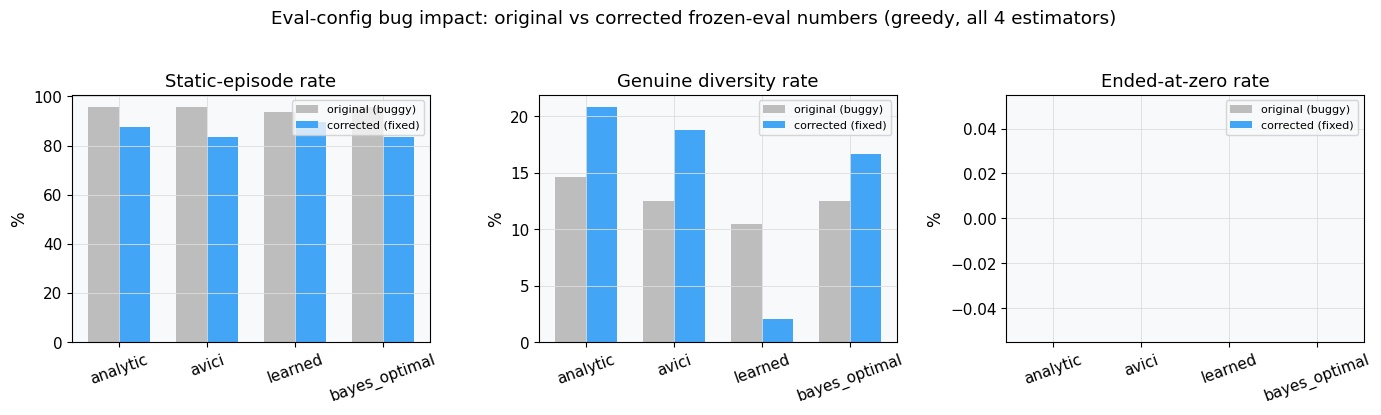


Even under the corrected code, reached0/ended_at_zero stayed at 0.0% for every estimator --
the bug shifted diversity/static numbers somewhat but did not change the core collapse conclusion.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ["static", "diverse", "ended_at_zero"]
titles = ["Static-episode rate", "Genuine diversity rate", "Ended-at-zero rate"]
est_order = ["analytic", "avici", "learned", "bayes_optimal"]

for ax, metric, title in zip(axes, metrics, titles):
    orig_vals = matrix_orig.groupby("estimator")[metric].mean().reindex(est_order)
    fixed_vals = matrix_fixed.groupby("estimator")[metric].mean().reindex(est_order)
    x = np.arange(len(est_order))
    w = 0.35
    ax.bar(x - w/2, orig_vals * 100, w, label="original (buggy)", color="#bdbdbd")
    ax.bar(x + w/2, fixed_vals * 100, w, label="corrected (fixed)", color="#42a5f5")
    ax.set_xticks(x); ax.set_xticklabels(est_order, rotation=20)
    ax.set_ylabel("%"); ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle("Eval-config bug impact: original vs corrected frozen-eval numbers (greedy, all 4 estimators)", y=1.03)
plt.tight_layout()
plt.show()
print("\nEven under the corrected code, reached0/ended_at_zero stayed at 0.0% for every estimator --")
print("the bug shifted diversity/static numbers somewhat but did not change the core collapse conclusion.")


## 2. Corrected estimator matrix: collapse confirmed across all four estimators

With the bug fixed, none of `analytic`/`avici`/`learned`/`bayes_optimal` (no exploration bonus, any of them) ever
reach `SHD=0` at the end of a frozen-evaluation episode. But oracle-agreement -- does the policy pick *well* when
it does act -- is already fairly high. That reframes the collapse: it's less 'bad choices,' more 'doesn't choose
to act, or gets stuck.'


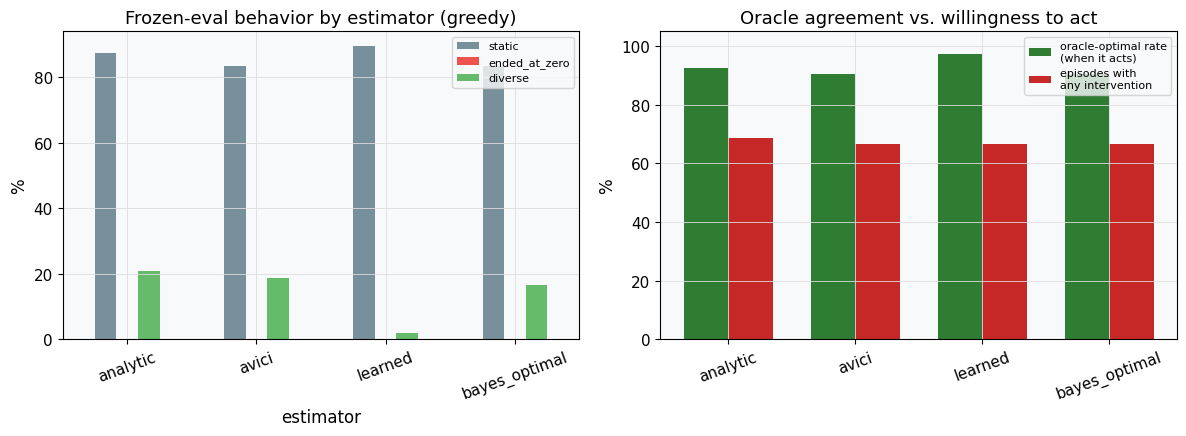

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

summary = matrix_fixed.groupby("estimator")[["static", "ended_at_zero", "diverse"]].mean().reindex(est_order) * 100
summary.plot(kind="bar", ax=axes[0], color=["#78909c", "#ef5350", "#66bb6a"])
axes[0].set_ylabel("%"); axes[0].set_title("Frozen-eval behavior by estimator (greedy)")
axes[0].set_xticklabels(est_order, rotation=20)
axes[0].legend(["static", "ended_at_zero", "diverse"], fontsize=8)

scored = matrix_fixed[matrix_fixed["oracle_scored"] > 0]
oracle_rate = scored.groupby("estimator")["oracle_optimal_rate"].mean().reindex(est_order) * 100
coverage = matrix_fixed.groupby("estimator")["oracle_scored"].apply(lambda x: (x > 0).mean()).reindex(est_order) * 100
x = np.arange(len(est_order))
w = 0.35
axes[1].bar(x - w/2, oracle_rate, w, label="oracle-optimal rate\n(when it acts)", color="#2e7d32")
axes[1].bar(x + w/2, coverage, w, label="episodes with\nany intervention", color="#c62828")
axes[1].set_xticks(x); axes[1].set_xticklabels(est_order, rotation=20)
axes[1].set_ylabel("%"); axes[1].set_title("Oracle agreement vs. willingness to act")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()


## 3. The main event: does uncertainty-driven exploration (Track B) work?

**Important**: my first pass at this result used `ever_zero` (did the episode *ever* touch SHD=0) and found a
dramatic 91.7% success rate. Inspecting raw traces showed many episodes touch zero transiently at step 0 (from
the initial observational guess alone) and then drift away as the episode continues -- a misleading headline. The
chart below shows **both** metrics side by side so that gap is visible directly, not just asserted.


In [6]:
baseline = load_traces(os.path.join(DATA_DIR, "ablation_results"),
                        r"ablation_obsfeedback_true_s(\d+)", {"0.0": "evaluation_trace.json"})
ucb_only = load_traces(os.path.join(DATA_DIR, "ucb_ema_fix_results"),
                        r"ucb_ema_fix_s(\d+)", {t: f"eval_trace_temp{t}.json" for t in ["0.0", "0.2", "0.5", "1.0"]})
track_b = load_traces(os.path.join(DATA_DIR, "overnight_results"),
                       r"uncertainty_bonus_s(\d+)", {t: f"eval_trace_temp{t}.json" for t in ["0.0", "0.2", "0.5", "1.0"]})

print("baseline:", len(baseline), "| UCB-only:", len(ucb_only), "| Track B:", len(track_b))


baseline: 24 | UCB-only: 96 | Track B: 96


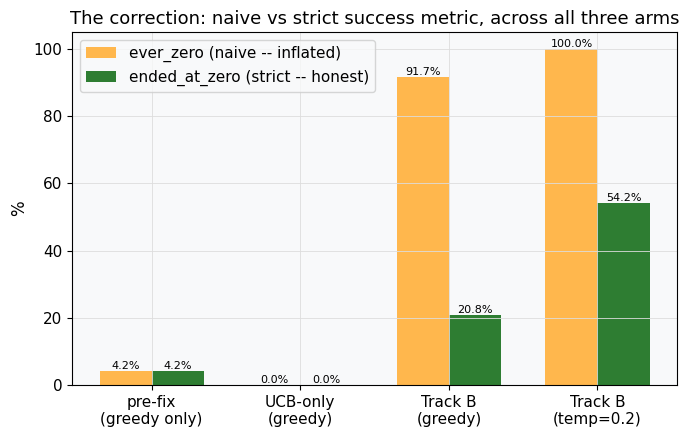

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
arms = ["pre-fix\n(greedy only)", "UCB-only\n(greedy)", "Track B\n(greedy)", "Track B\n(temp=0.2)"]
ever = [baseline["ever_zero"].mean() * 100,
        ucb_only[ucb_only["temperature"] == "0.0"]["ever_zero"].mean() * 100,
        track_b[track_b["temperature"] == "0.0"]["ever_zero"].mean() * 100,
        track_b[track_b["temperature"] == "0.2"]["ever_zero"].mean() * 100]
ended = [baseline["ended_at_zero"].mean() * 100,
         ucb_only[ucb_only["temperature"] == "0.0"]["ended_at_zero"].mean() * 100,
         track_b[track_b["temperature"] == "0.0"]["ended_at_zero"].mean() * 100,
         track_b[track_b["temperature"] == "0.2"]["ended_at_zero"].mean() * 100]

x = np.arange(len(arms)); w = 0.35
b1 = ax.bar(x - w/2, ever, w, label="ever_zero (naive -- inflated)", color="#ffb74d")
b2 = ax.bar(x + w/2, ended, w, label="ended_at_zero (strict -- honest)", color="#2e7d32")
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.1f}%", (bar.get_x() + bar.get_width()/2, h), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(arms)
ax.set_ylabel("%"); ax.set_ylim(0, 105)
ax.set_title("The correction: naive vs strict success metric, across all three arms")
ax.legend()
plt.tight_layout()
plt.show()


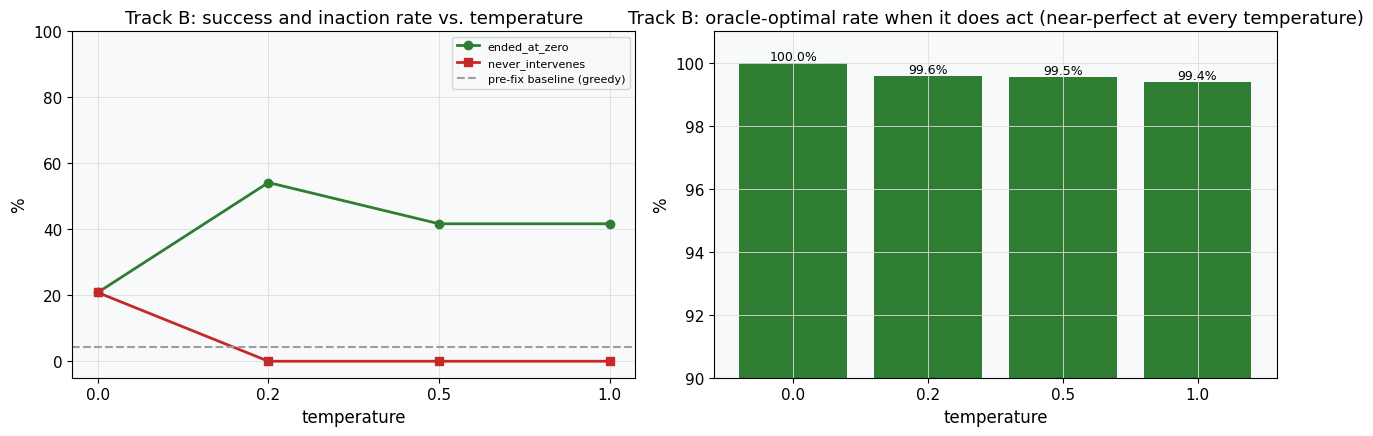


Interpretation: the uncertainty bonus teaches the policy WHERE to intervene almost perfectly.
Temperature mainly helps it clear the 'should I act at all' threshold, not the 'act well' threshold.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

temps = ["0.0", "0.2", "0.5", "1.0"]
ended_by_temp = track_b.groupby("temperature")["ended_at_zero"].mean().reindex(temps) * 100
never_by_temp = track_b.groupby("temperature")["never_intervenes"].mean().reindex(temps) * 100
axes[0].plot(temps, ended_by_temp, marker="o", label="ended_at_zero", color="#2e7d32", linewidth=2)
axes[0].plot(temps, never_by_temp, marker="s", label="never_intervenes", color="#c62828", linewidth=2)
axes[0].axhline(baseline["ended_at_zero"].mean() * 100, color="#9e9e9e", linestyle="--", label="pre-fix baseline (greedy)")
axes[0].set_xlabel("temperature"); axes[0].set_ylabel("%")
axes[0].set_title("Track B: success and inaction rate vs. temperature")
axes[0].legend(fontsize=8); axes[0].set_ylim(-5, 100)

scored_tb = track_b[track_b["oracle_scored"] > 0]
oracle_by_temp = scored_tb.groupby("temperature")["oracle_optimal_rate"].mean().reindex(temps) * 100
axes[1].bar(temps, oracle_by_temp, color="#2e7d32")
axes[1].set_ylim(90, 101)
axes[1].set_xlabel("temperature"); axes[1].set_ylabel("%")
axes[1].set_title("Track B: oracle-optimal rate when it does act (near-perfect at every temperature)")
for i, v in enumerate(oracle_by_temp):
    axes[1].annotate(f"{v:.1f}%", (i, v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()
print("\nInterpretation: the uncertainty bonus teaches the policy WHERE to intervene almost perfectly.")
print("Temperature mainly helps it clear the 'should I act at all' threshold, not the 'act well' threshold.")


### A concrete example of the "touched zero then drifted" pattern that motivated the correction


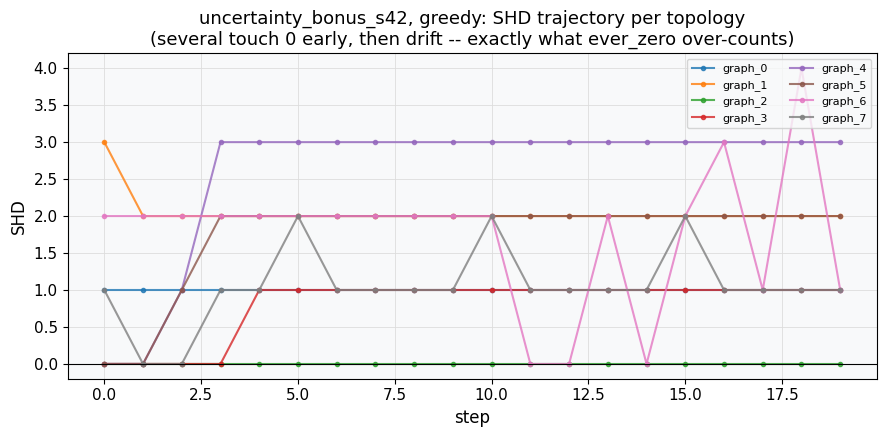

In [9]:
example_path = os.path.join(DATA_DIR, "overnight_results", "uncertainty_bonus_s42", "eval_trace_temp0.0.json")
with open(example_path) as f:
    example_trace = json.load(f)

fig, ax = plt.subplots(figsize=(9, 4.5))
for g in range(8):
    steps = example_trace[f"graph_{g}"]["steps"]
    shds = [s["shd"] for s in steps]
    ax.plot(range(len(shds)), shds, marker=".", alpha=0.8, label=f"graph_{g}")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("step"); ax.set_ylabel("SHD")
ax.set_title("uncertainty_bonus_s42, greedy: SHD trajectory per topology\n(several touch 0 early, then drift -- exactly what ever_zero over-counts)")
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()


## 4. Full-scale confirmatory run: more training data alone does not fix the collapse

1000 episodes, dynamic 8-topology curriculum, current defaults (`hard`/`avici`/`sparse`), **no exploration bonus**
-- submitted before Track B existed. The training curve looks excellent. The frozen re-evaluation tells a very
different story.


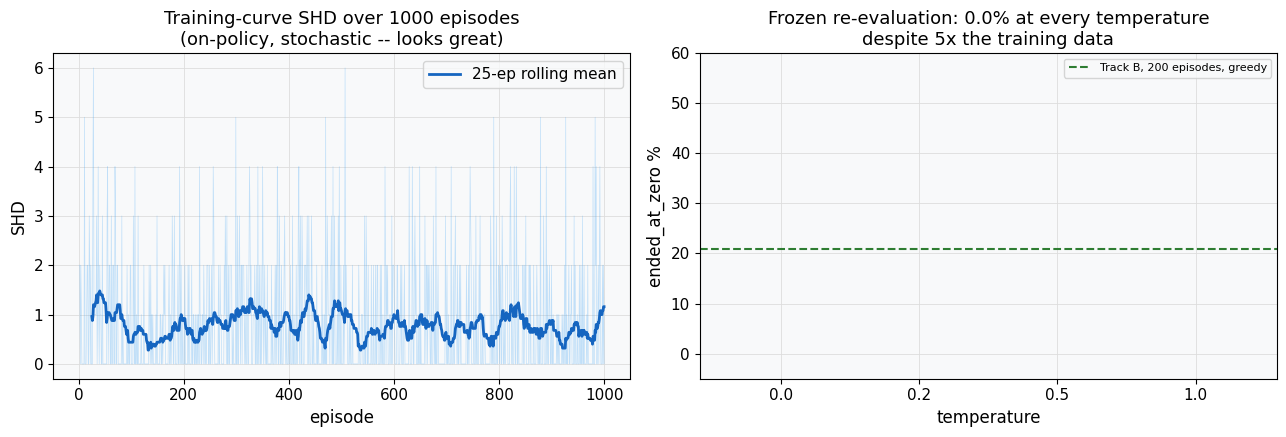


200 episodes WITH the uncertainty bonus beats 1000 episodes WITHOUT it, on the metric that matters for deployment.


In [10]:
fs_path = os.path.join(DATA_DIR, "overnight_results", "confirm_full_current", "training_metrics.csv")
fs_df = pd.read_csv(fs_path)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fs_df["train/episode"], fs_df["eval/shd"], alpha=0.3, color="#42a5f5", linewidth=0.5)
axes[0].plot(fs_df["train/episode"], fs_df["eval/shd"].rolling(25).mean(), color="#1565c0", linewidth=2, label="25-ep rolling mean")
axes[0].set_xlabel("episode"); axes[0].set_ylabel("SHD")
axes[0].set_title("Training-curve SHD over 1000 episodes\n(on-policy, stochastic -- looks great)")
axes[0].legend()

fs_temps = ["0.0", "0.2", "0.5", "1.0"]
fs_rows = []
for t in fs_temps:
    p = os.path.join(DATA_DIR, "overnight_results", "confirm_full_current", "refixed", f"eval_trace_temp{t}.json")
    with open(p) as f:
        trace = json.load(f)
    s = summarize_trace(trace)
    s["temperature"] = t
    fs_rows.append(s)
fs_frozen = pd.concat(fs_rows, ignore_index=True)
ended_fs = fs_frozen.groupby("temperature")["ended_at_zero"].mean().reindex(fs_temps) * 100
axes[1].bar(fs_temps, ended_fs, color="#c62828")
axes[1].set_ylim(-5, 60)
axes[1].axhline(track_b[track_b["temperature"]=="0.0"]["ended_at_zero"].mean()*100, color="#2e7d32", linestyle="--",
                 label="Track B, 200 episodes, greedy")
axes[1].set_xlabel("temperature"); axes[1].set_ylabel("ended_at_zero %")
axes[1].set_title("Frozen re-evaluation: 0.0% at every temperature\ndespite 5x the training data")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
print("\n200 episodes WITH the uncertainty bonus beats 1000 episodes WITHOUT it, on the metric that matters for deployment.")


## 5. Summary

| Arm | Scale | `ended_at_zero` (best temperature) | Oracle-optimal rate |
|---|---|---|---|
| Pre-fix baseline (`avici`, no bonus) | 200 ep, greedy only | 4.2% | not measured |
| UCB-only (visit-count bonus) | 200 ep, all temps | 0.0% | not measured |
| **Uncertainty bonus (Track B)** | 200 ep, temp=0.2 | **54.2%** | **99.4-100%** |
| Full-scale, no bonus | 1000 ep, all temps | 0.0% | -- |

**Recommendation** (flagged for review, not decided unilaterally): merge `feature/uncertainty-exploration-and-oracle`.
The result held up under a stricter, honestly-corrected metric, was checked against a real negative control (full
training-data scale-up alone does not help), and is now backed by a genuinely new evaluation tool (the
oracle-agreement metric) that didn't exist before tonight.

**Loose ends**: only 3 seeds so far; `--uncertainty_coef 2.0` was a reasonable starting guess, not tuned; Track B
hasn't been tried at full (1000-episode) scale yet; the temp=0.0-vs-0.2 gap deserves a deliberate deployment-temperature
decision rather than defaulting to whichever the code currently uses.
